# Selected XGBoost error analysis

This notebook describes the held-out errors of the frozen market-only XGBoost model. The analysis is diagnostic only: it does not alter the model, its features, or its hyperparameters. Positive signed errors indicate underprediction of realized downside risk.

In [16]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MaxNLocator, PercentFormatter
from sklearn.metrics import mean_absolute_error, mean_squared_error

project_root = Path.cwd().resolve()
while not (project_root / 'src').is_dir():
    if project_root == project_root.parent:
        raise RuntimeError('Project root could not be located.')
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.modeling.tabular_selection import PREDICTION, TARGET
from src.utils.configuration import get_paths_config
from src.visualization.style import (
    COLOR_PALETTE, SINGLE_PANEL_SIZE, apply_matplotlib_layout,
    set_matplotlib_style,
)

paths = get_paths_config()
modeling_tables = paths.tables / 'modeling'
set_matplotlib_style()

In [17]:
predictions = pd.read_parquet(
    modeling_tables / 'final_models_test_predictions.parquet'
)
errors = predictions.loc[predictions['model'].eq('XGBoost')].copy()
market = pd.read_parquet(
    paths.processed / 'modeling' / 'modeling_sample.parquet',
    columns=['report_period', 'permno', 'sample_split', 'market_cap_usd'],
)
market = market.loc[market['sample_split'].eq('test')].drop(columns='sample_split')
errors = errors.merge(
    market, on=['report_period', 'permno'], how='left', validate='one_to_one'
)
errors['signed_error'] = errors[TARGET] - errors[PREDICTION]
errors['absolute_error'] = errors['signed_error'].abs()
errors['squared_error'] = errors['signed_error'] ** 2
errors['predicted_decile'] = np.ceil(
    10 * errors.groupby('report_period')[PREDICTION].rank(method='first', pct=True)
).astype(int).clip(1, 10)
errors['realized_decile'] = np.ceil(
    10 * errors.groupby('report_period')[TARGET].rank(method='first', pct=True)
).astype(int).clip(1, 10)
errors['size_quintile'] = np.ceil(
    5 * errors.groupby('report_period')['market_cap_usd'].rank(method='first', pct=True)
).astype(int).clip(1, 5)
errors.to_parquet(
    modeling_tables / 'selected_xgboost_test_error_observations.parquet',
    index=False,
)

## Calibration across predicted-risk deciles

In [18]:
calibration = errors.groupby('predicted_decile', as_index=False).agg(
    observations=('permno', 'size'),
    mean_prediction=(PREDICTION, 'mean'),
    mean_realized_drawdown=(TARGET, 'mean'),
    mean_signed_error=('signed_error', 'mean'),
    mean_absolute_error=('absolute_error', 'mean'),
)
calibration.to_csv(
    modeling_tables / 'selected_xgboost_calibration_by_predicted_decile.csv',
    index=False,
)
calibration.rename(columns={
    'predicted_decile': 'Predicted decile', 'observations': 'Observations',
    'mean_prediction': 'Mean prediction',
    'mean_realized_drawdown': 'Mean realized drawdown',
    'mean_signed_error': 'Mean signed error',
    'mean_absolute_error': 'MAE',
}).to_latex(
    paths.tables / '04_07_xgboost_calibration_by_predicted_decile.tex',
    index=False, escape=True, float_format='%.4f',
    caption='Selected XGBoost calibration across predicted-risk deciles in the test sample.',
    label='tab:xgboost-calibration-by-predicted-decile',
)
display(calibration.style.format({
    'observations': '{:,}', 'mean_prediction': '{:.2%}',
    'mean_realized_drawdown': '{:.2%}', 'mean_signed_error': '{:.2%}',
    'mean_absolute_error': '{:.2%}',
}))

,predicted_decile,observations,mean_prediction,mean_realized_drawdown,mean_signed_error,mean_absolute_error
0,1,"3,046",10.54%,10.41%,-0.14%,4.63%
1,2,"3,053",12.79%,13.10%,0.31%,5.40%
2,3,"3,049",14.47%,14.68%,0.21%,6.10%
3,4,"3,053",16.43%,17.00%,0.57%,7.12%
4,5,"3,052",19.07%,19.98%,0.91%,8.05%
5,6,"3,050",22.45%,23.29%,0.84%,9.24%
6,7,"3,052",26.39%,27.01%,0.62%,10.26%
7,8,"3,050",31.24%,32.38%,1.14%,11.54%
8,9,"3,052",37.40%,39.20%,1.79%,12.69%
9,10,"3,054",49.03%,52.09%,3.06%,16.16%


## Errors across realized drawdown deciles

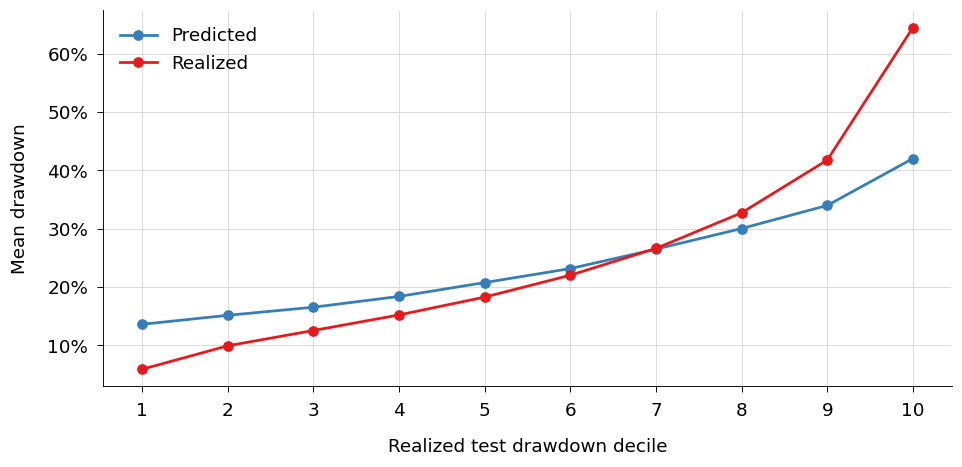

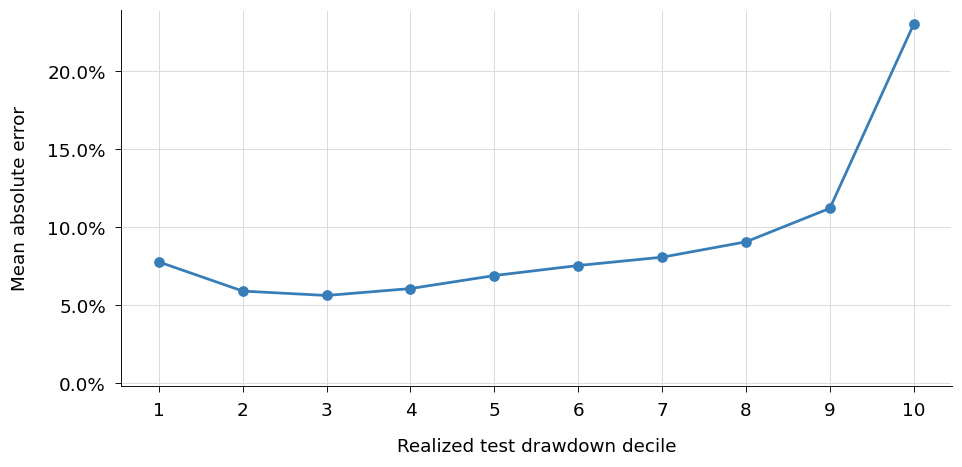

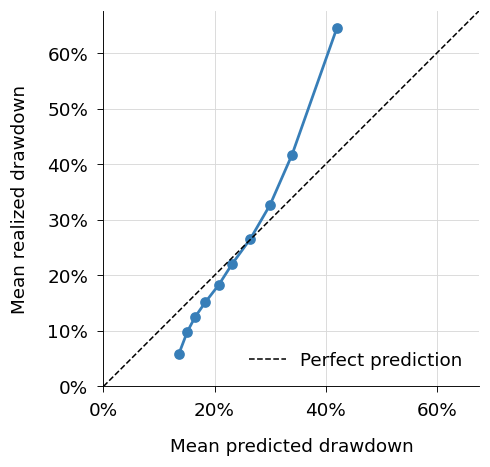

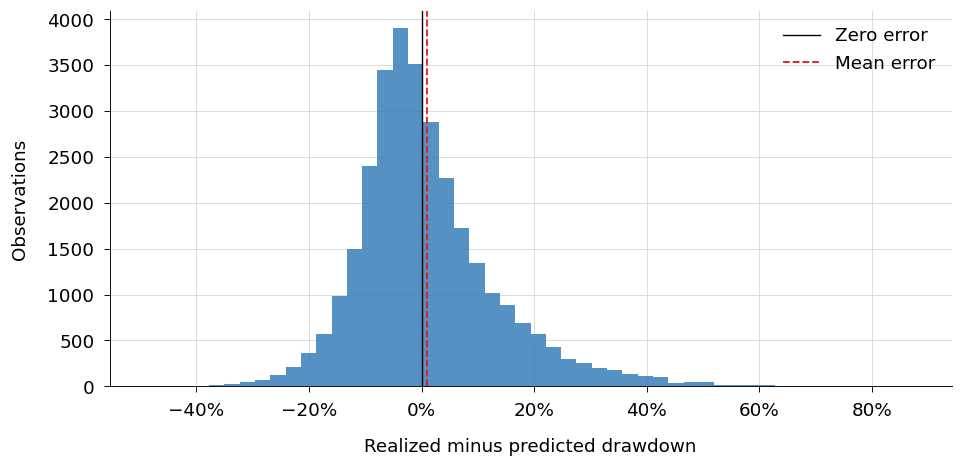

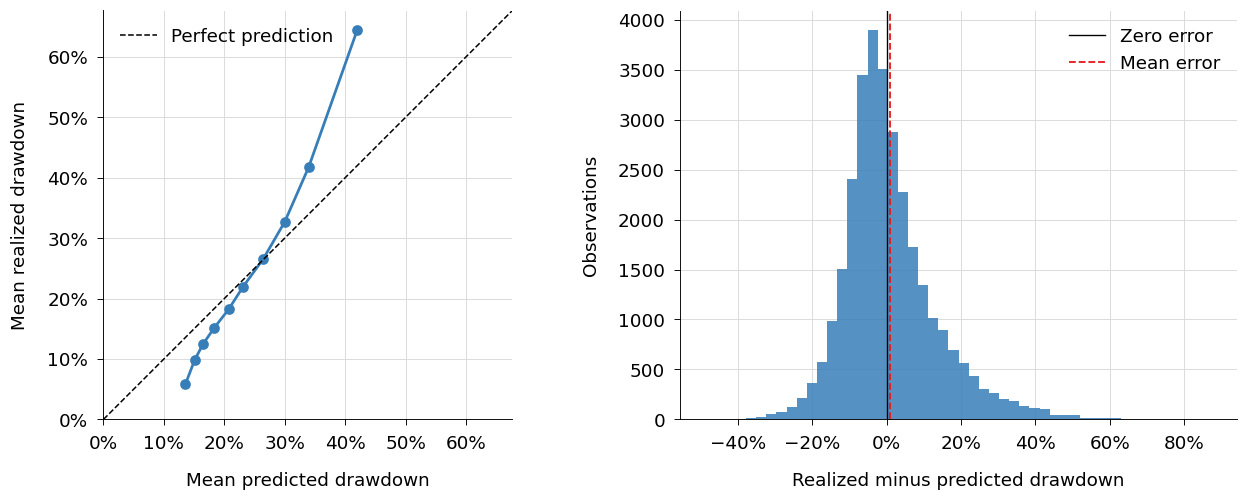

In [19]:
realized_errors = errors.groupby('realized_decile', as_index=False).agg(
    observations=('permno', 'size'),
    mean_realized_drawdown=(TARGET, 'mean'),
    mean_prediction=(PREDICTION, 'mean'),
    mean_signed_error=('signed_error', 'mean'),
    mean_absolute_error=('absolute_error', 'mean'),
)
realized_errors.to_csv(
    modeling_tables / 'selected_xgboost_error_by_realized_decile.csv',
    index=False,
)
realized_errors.rename(columns={
    'realized_decile': 'Realized decile', 'observations': 'Observations',
    'mean_realized_drawdown': 'Mean realized drawdown',
    'mean_prediction': 'Mean prediction',
    'mean_signed_error': 'Mean signed error',
    'mean_absolute_error': 'MAE',
}).to_latex(
    paths.tables / '04_07_xgboost_error_by_realized_decile.tex',
    index=False, escape=True, float_format='%.4f',
    caption='Selected XGBoost errors across realized drawdown deciles in the test sample.',
    label='tab:xgboost-error-by-realized-decile',
)

figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
axis.plot(realized_errors['realized_decile'],
          realized_errors['mean_prediction'], marker='o',
          color=COLOR_PALETTE[0], label='Predicted')
axis.plot(realized_errors['realized_decile'],
          realized_errors['mean_realized_drawdown'], marker='o',
          color=COLOR_PALETTE[1], label='Realized')
axis.set_xlabel('Realized test drawdown decile')
axis.set_ylabel('Mean drawdown')
axis.xaxis.set_major_locator(MaxNLocator(integer=True))
axis.yaxis.set_major_formatter(PercentFormatter(1.0))
axis.legend(frameon=False)
apply_matplotlib_layout(figure)
figure.savefig(
    paths.figures
    / '04_09_xgboost_test_predicted_vs_realized_by_realized_decile.pdf'
)
plt.show()

figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
axis.plot(realized_errors['realized_decile'],
          realized_errors['mean_absolute_error'], marker='o',
          color=COLOR_PALETTE[0])
axis.set_xlabel('Realized test drawdown decile')
axis.set_ylabel('Mean absolute error')
axis.set_ylim(bottom=-0.002)
axis.xaxis.set_major_locator(MaxNLocator(integer=True))
axis.yaxis.set_major_formatter(PercentFormatter(1.0))
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / '04_09_xgboost_test_mae_by_realized_decile.pdf')
plt.show()

figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
axis.plot(
    realized_errors['mean_prediction'],
    realized_errors['mean_realized_drawdown'],
    marker='o', color=COLOR_PALETTE[0],
)
plot_limit = 1.05 * max(
    realized_errors['mean_prediction'].max(),
    realized_errors['mean_realized_drawdown'].max(),
)
axis.plot(
    [0, plot_limit], [0, plot_limit], color='black', linewidth=1.0,
    linestyle='--', label='Perfect prediction',
)

axis.set_xlabel('Mean predicted drawdown')
axis.set_ylabel('Mean realized drawdown')
axis.set_xlim(0, plot_limit)
axis.set_ylim(0, plot_limit)
axis.set_aspect('equal', adjustable='box')
axis.xaxis.set_major_formatter(PercentFormatter(1.0))
axis.yaxis.set_major_formatter(PercentFormatter(1.0))
axis.legend(frameon=False)
apply_matplotlib_layout(figure)
figure.savefig(
    paths.figures
    / '04_09_xgboost_test_realized_vs_predicted_by_realized_decile.pdf',
    bbox_inches=None,
)
plt.show()

figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
axis.hist(
    errors['signed_error'], bins=50, color=COLOR_PALETTE[0], alpha=0.85
)
axis.axvline(0, color='black', linewidth=0.9, label='Zero error')
axis.axvline(
    errors['signed_error'].mean(), color=COLOR_PALETTE[1],
    linewidth=1.2, linestyle='--', label='Mean error',
)
axis.set_xlabel('Realized minus predicted drawdown')
axis.set_ylabel('Observations')
axis.xaxis.set_major_formatter(PercentFormatter(1.0))
axis.legend(frameon=False)
apply_matplotlib_layout(figure)
figure.savefig(
    paths.figures / '04_09_xgboost_test_signed_error_distribution.pdf'
)
plt.show()

figure, axes = plt.subplots(1, 2, figsize=(12, 4.8))
calibration_axis, error_axis = axes

calibration_axis.plot(
    realized_errors['mean_prediction'],
    realized_errors['mean_realized_drawdown'],
    marker='o', color=COLOR_PALETTE[0],
)
calibration_axis.plot(
    [0, plot_limit], [0, plot_limit], color='black', linewidth=1.0,
    linestyle='--', label='Perfect prediction',
)
calibration_axis.set_xlabel('Mean predicted drawdown')
calibration_axis.set_ylabel('Mean realized drawdown')
calibration_axis.set_xlim(0, plot_limit)
calibration_axis.set_ylim(0, plot_limit)
calibration_axis.set_aspect('equal', adjustable='box')
calibration_axis.xaxis.set_major_formatter(PercentFormatter(1.0))
calibration_axis.yaxis.set_major_formatter(PercentFormatter(1.0))
calibration_axis.legend(frameon=False)

error_axis.hist(
    errors['signed_error'], bins=50, color=COLOR_PALETTE[0], alpha=0.85
)
error_axis.axvline(0, color='black', linewidth=0.9, label='Zero error')
error_axis.axvline(
    errors['signed_error'].mean(), color=COLOR_PALETTE[1],
    linewidth=1.2, linestyle='--', label='Mean error',
)
error_axis.set_xlabel('Realized minus predicted drawdown')
error_axis.set_ylabel('Observations')
error_axis.xaxis.set_major_formatter(PercentFormatter(1.0))
error_axis.legend(frameon=False)

apply_matplotlib_layout(figure)
figure.savefig(
    paths.figures / '04_09_xgboost_test_calibration_and_signed_errors.pdf'
)
plt.show()

## Temporal and firm-size diagnostics

,report_period,observations,mae,rmse,mean_signed_error,spearman
0,2024-03-31 00:00:00,"4,005",8.27%,12.20%,1.98%,0.800
1,2024-06-30 00:00:00,"3,946",8.72%,11.73%,-3.05%,0.765
2,2024-09-30 00:00:00,"3,869",8.24%,12.18%,1.88%,0.730
3,2024-12-31 00:00:00,"3,819",11.97%,15.59%,9.37%,0.728
4,2025-03-31 00:00:00,"3,767",9.46%,12.07%,-4.22%,0.721
5,2025-06-30 00:00:00,"3,733",8.34%,11.62%,-0.15%,0.717
6,2025-09-30 00:00:00,"3,706",9.47%,12.85%,-0.08%,0.747
7,2025-12-31 00:00:00,"3,666",8.53%,11.93%,1.71%,0.698


,size_quintile,observations,mean_market_cap,mean_signed_error,mean_absolute_error
0,1,"6,099","$26,746,511",2.74%,13.52%
1,2,"6,102","$201,461,717",0.35%,9.82%
2,3,"6,102","$883,826,654",0.17%,8.65%
3,4,"6,102","$3,650,210,637",0.67%,7.28%
4,5,"6,106","$74,230,732,364",0.74%,6.34%


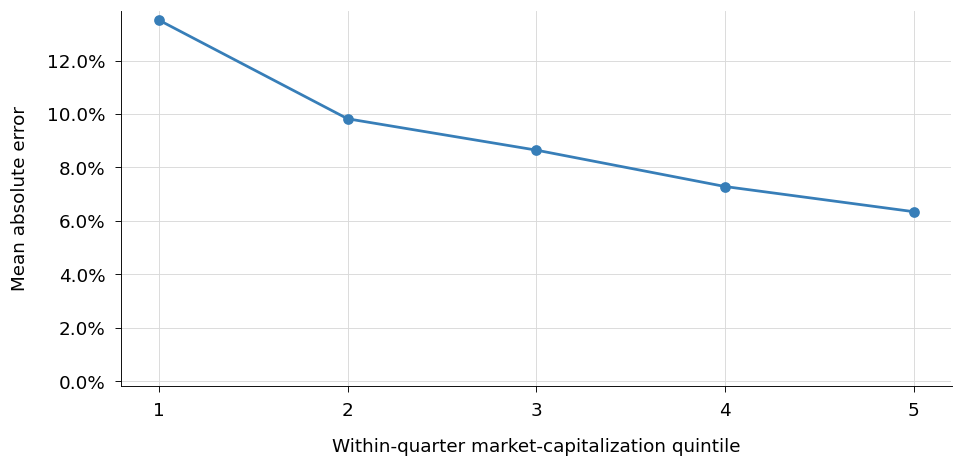

In [20]:
quarterly = errors.groupby('report_period').apply(
    lambda group: pd.Series({
        'observations': len(group),
        'mae': mean_absolute_error(group[TARGET], group[PREDICTION]),
        'rmse': mean_squared_error(group[TARGET], group[PREDICTION]) ** 0.5,
        'mean_signed_error': group['signed_error'].mean(),
        'spearman': group[TARGET].corr(group[PREDICTION], method='spearman'),
    }), include_groups=False,
).reset_index()
size = errors.groupby('size_quintile', as_index=False).agg(
    observations=('permno', 'size'),
    mean_market_cap=('market_cap_usd', 'mean'),
    mean_signed_error=('signed_error', 'mean'),
    mean_absolute_error=('absolute_error', 'mean'),
)
quarterly.to_csv(modeling_tables / 'selected_xgboost_quarterly_test_errors.csv', index=False)
size.to_csv(modeling_tables / 'selected_xgboost_test_errors_by_size.csv', index=False)
quarterly.assign(
    report_period=pd.to_datetime(quarterly['report_period']).dt.to_period('Q').astype(str)
).rename(columns={
    'report_period': 'Test quarter', 'observations': 'Observations',
    'mae': 'MAE', 'rmse': 'RMSE', 'mean_signed_error': 'Mean signed error',
    'spearman': 'Spearman',
}).to_latex(
    paths.tables / '04_07_xgboost_quarterly_test_errors.tex',
    index=False, escape=True, float_format='%.4f',
    caption='Quarterly test-error diagnostics for the selected XGBoost model.',
    label='tab:xgboost-quarterly-test-errors',
)
size.rename(columns={
    'size_quintile': 'Size quintile', 'observations': 'Observations',
    'mean_market_cap': 'Mean market capitalization',
    'mean_signed_error': 'Mean signed error',
    'mean_absolute_error': 'MAE',
}).to_latex(
    paths.tables / '04_07_xgboost_test_errors_by_size.tex',
    index=False, escape=True, float_format='%.4f',
    caption='Selected XGBoost test errors across within-quarter firm-size quintiles.',
    label='tab:xgboost-test-errors-by-size',
)
display(quarterly.style.format({
    'observations': '{:,.0f}', 'mae': '{:.2%}', 'rmse': '{:.2%}',
    'mean_signed_error': '{:.2%}', 'spearman': '{:.3f}',
}))
display(size.style.format({
    'observations': '{:,}', 'mean_market_cap': '${:,.0f}',
    'mean_signed_error': '{:.2%}', 'mean_absolute_error': '{:.2%}',
}))

figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
axis.plot(size['size_quintile'], size['mean_absolute_error'],
          marker='o', color=COLOR_PALETTE[0])
axis.set_xlabel('Within-quarter market-capitalization quintile')
axis.set_ylabel('Mean absolute error')
axis.set_ylim(bottom=-0.002)
axis.xaxis.set_major_locator(MaxNLocator(integer=True))
axis.yaxis.set_major_formatter(PercentFormatter(1.0))
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / '04_09_xgboost_test_mae_by_size.pdf')
plt.show()